<a href="https://colab.research.google.com/github/hesther/teaching/blob/main/aimat2026/Notebook_AIMat2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to code a GNN from scratch (AIMat Summer School 2026)

In [1]:
!pip -q install rdkit numpy scikit-learn pandas torch

In [2]:
from rdkit import Chem
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In this workshop, we will explore how to code a graph neural network, specifically a directed message passing neural network D-MPNN from scratch. First, we will build all necessary functionalities by hand (part A), and then later (part B) port our work into `pytorch_geometric`, which automates a lot of boilerplate code e.g. regarding batching.

## Part A: Coding a GNN from scratch
### What you will learn

- How to represent a molecule as a directed bond graph
- How to featurize atoms and bonds
- How to build a graph using index vectors
- How to implement message passing without any graph library
- How to aggregate node features into molecular fingerprints and make property predictions


We will use the Cheminformatics package `rdkit` to load and featurize molecules:


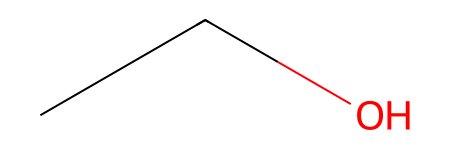

In [3]:
mol = Chem.MolFromSmiles("CCO")
mol

It gives us a convenient way to obtain atom and bond features:

In [4]:
mol.GetAtoms()

In [5]:
mol.GetAtoms()[0]

In [6]:
mol.GetAtoms()[0].GetSymbol()

'C'

Let us formalize this into a function that obtains revelant atom properties:

In [7]:
def atom_features(atom):
  fatom = [atom.GetSymbol(),
              atom.GetTotalDegree(),
              atom.GetFormalCharge(),
              atom.GetTotalNumHs(),
              atom.GetHybridization(),
              atom.GetIsAromatic(),
              atom.GetMass()
              ]
  return fatom

In [8]:
atom_features(mol.GetAtoms()[0])

['C', 4, 0, 3, rdkit.Chem.rdchem.HybridizationType.SP3, False, 12.011]

In [9]:
atom_features(mol.GetAtoms()[1])

['C', 4, 0, 2, rdkit.Chem.rdchem.HybridizationType.SP3, False, 12.011]

In [10]:
atom_features(mol.GetAtoms()[2])

['O', 2, 0, 1, rdkit.Chem.rdchem.HybridizationType.SP3, False, 15.999]

Now, for using this information as a feature vector, we need to put this into numbers. The easiest way to do so is to one-hot encode the information:

In [11]:
def one_hot(value, choices):
    """One-hot encode `value` against `choices`. Unknown values map to an extra 'other' bin."""
    encoding = [0] * (len(choices) + 1)          # +1 for 'other'
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding

one_hot('C', ['C','N','O'])

[1, 0, 0, 0]

We can then rewrite the `atom_features()` function:

In [12]:
ATOM_FDIM = 39
def atom_features(atom):
    fatom = one_hot(atom.GetSymbol(), ['H', 'C', 'N', 'O', 'F', 'Si', 'P', 'S', 'Cl', 'Br', 'I']) + \
        one_hot(atom.GetTotalDegree(), [0, 1, 2, 3, 4, 5]) + \
        one_hot(atom.GetFormalCharge(), [-1, -2, 1, 2, 0]) + \
        one_hot(int(atom.GetTotalNumHs()), [0, 1, 2, 3, 4]) + \
        one_hot(int(atom.GetHybridization()),[Chem.rdchem.HybridizationType.SP,
                                                        Chem.rdchem.HybridizationType.SP2,
                                                        Chem.rdchem.HybridizationType.SP3,
                                                        Chem.rdchem.HybridizationType.SP3D,
                                                        Chem.rdchem.HybridizationType.SP3D2
                                                        ]) + \
        [1 if atom.GetIsAromatic() else 0] + \
        [atom.GetMass() * 0.01]
    return fatom

In [13]:
atom_features(mol.GetAtoms()[0])

[0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0.12011]

## Molecule graph representation

Let us now build a custom molecule graph class:

In [14]:
class MolGraph:
    """
    Undirected molecule graph: atom features + neighbor index.
    """
    def __init__(self, smiles: str):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f'Invalid SMILES: {smiles}')

        self.n_atoms = mol.GetNumAtoms()

        # Atom features: list of length-ATOM_FDIM lists
        self.f_atoms = [atom_features(a) for a in mol.GetAtoms()]

        # Neighbor list: for each atom, indices of bonded atoms
        adj = [[] for _ in range(self.n_atoms)]
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            adj[i].append(j)
            adj[j].append(i)

        self.neighbors = adj
        self.max_degree = max(len(row) for row in adj) if any(adj) else 1

In [15]:
g = MolGraph('CCO')

In [16]:
g.f_atoms

[[0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0.12011],
 [0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0.12011],
 [0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0.15999000000000002]]

In [17]:
g.neighbors

[[1], [0, 2], [1]]

In [18]:
class BatchMolGraph:
    """
    Concatenates a list of MolGraphs into one set of tensors.
   """
    def __init__(self, graphs):
        f_atoms_all   = []
        neighbors_all = []
        degrees_all   = []
        self.a_scope  = []

        global_max_degree = max(g.max_degree for g in graphs)

        atom_offset = 0
        for g in graphs:
            f_atoms_all.extend(g.f_atoms)

            for v, row in enumerate(g.neighbors):
                degree = len(row)
                degrees_all.append(degree)
                shifted = [idx + atom_offset for idx in row]
                # Pad with the atom index (this is masked later)
                idx_v = v + atom_offset
                shifted += [idx_v] * (global_max_degree - degree)
                neighbors_all.append(shifted)

            self.a_scope.append((atom_offset, g.n_atoms))
            atom_offset += g.n_atoms

        self.f_atoms   = torch.FloatTensor(f_atoms_all)    # (total_atoms, ATOM_FDIM)
        self.neighbors = torch.LongTensor(neighbors_all)   # (total_atoms, max_degree)
        self.degrees   = torch.LongTensor(degrees_all)     # (total_atoms,)

In [19]:
bg = BatchMolGraph([MolGraph('CC'), MolGraph('CCO')])

In [20]:
bg.f_atoms.shape, bg.neighbors.shape, bg.degrees, bg.a_scope

(torch.Size([5, 39]),
 torch.Size([5, 2]),
 tensor([1, 1, 1, 2, 1]),
 [(0, 2), (2, 3)])

We can now code our own graph convolution:

In [21]:
class GCNLayer(nn.Module):
    """
    Custom graph convolutional layer
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)

    def forward(
        self,
        h,              # (total_atoms, in_features)
        neighbors,  # (total_atoms, max_degree)
        degrees,    # (total_atoms,)
    ):

        m = torch.relu(self.linear(h))             # (total_atoms, out_features)
        neighbor_msgs = m[neighbors]               # (total_atoms, max_degree, out_features)

        #mask:
        max_degree = neighbors.size(1)
        k_idx = torch.arange(max_degree)          # (max_degree,)
        mask = (k_idx.unsqueeze(0) < degrees.unsqueeze(1)).float() # (total_atoms, max_degree)
        neighbor_msgs = neighbor_msgs * mask.unsqueeze(2)          # zero out padding

        agg = neighbor_msgs.sum(dim=1)                             # (total_atoms, out_features)
        safe_deg = degrees.float().clamp(min=1).unsqueeze(1)       # (total_atoms, 1)
        agg = agg / safe_deg                                        # mean over true neighbors

        return h + agg                                             # (total_atoms, out_features)

class GCN(nn.Module):
    """
    Custom GNN
    """
    def __init__(
        self,
        hidden_size: int = 128,
        depth: int = 3,
        ffn_hidden: int = 128,
        output_size: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()

        # Project atom features into the working hidden dimension
        self.input_proj = nn.Linear(ATOM_FDIM, hidden_size)

        # GCN layers
        self.gcn_layers = nn.ModuleList([
            GCNLayer(hidden_size, hidden_size)
            for _ in range(depth)
        ])
        self.dropout = nn.Dropout(dropout)

        # MLP readout head
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, ffn_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, output_size),
        )

    def forward(self, batch: BatchMolGraph) -> torch.Tensor:
        neighbors = batch.neighbors  # (total_atoms, max_degree)
        degrees   = batch.degrees    # (total_atoms,)

        # Project atom features into hidden space
        h = torch.relu(self.input_proj(batch.f_atoms))  # (total_atoms, hidden_size)

        # Message passing
        for layer in self.gcn_layers:
            h = layer(h, neighbors, degrees)
            h = self.dropout(h)

        # Per-molecule mean pooling
        mol_vecs = []
        for (start, size) in batch.a_scope:
            mol_vecs.append(h[start : start + size].mean(dim=0))
        mol_vecs = torch.stack(mol_vecs, dim=0)   # (num_mols, hidden_size)

        return self.ffn(mol_vecs)                  # (num_mols, output_size)

In [22]:
model = GCN(hidden_size=300, depth=3)
bg = BatchMolGraph([MolGraph(s) for s in ['CC', 'c1ccccc1', 'CCO']])
model(bg)


tensor([[-0.0551],
        [-0.0478],
        [-0.0368]], grad_fn=<AddmmBackward0>)

In [23]:
model

GCN(
  (input_proj): Linear(in_features=39, out_features=300, bias=True)
  (gcn_layers): ModuleList(
    (0-2): 3 x GCNLayer(
      (linear): Linear(in_features=300, out_features=300, bias=False)
    )
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (ffn): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Let's train it on a dataset of experimental solubilities:

In [24]:
df = pd.read_csv("https://github.com/hesther/rxn_workshop/raw/main/data/esol/train_full.csv")
df = df[['smiles', 'logSolubility']].rename(columns={'logSolubility': 'y'})
df

,smiles,y
0,CC/C=C\C,-2.540
1,O=C1NC(=O)NC(=O)C1(CC)CC=C(C)C,-2.253
2,Cc1[nH]c(=O)n(c(=O)c1Cl)C(C)(C)C,-2.484
3,CC/C=C/C,-2.540
4,ClC(Cl)C(c1ccc(Cl)cc1)c2ccc(Cl)cc2,-7.200
...,...,...
897,O2c1ccc(N)cc1N(C)C(=O)c3cc(C)ccc23,-3.928
898,CCCCCCCC#C,-4.240
899,CCCC(=O)OCC,-1.360
900,CC(=O)OCC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3C(...,-4.880


In [25]:
class MolDataset(Dataset):
    def __init__(self, smiles, targets):
        self.smiles  = smiles
        self.targets = targets

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        return self.smiles[idx], self.targets[idx]


def collate_fn(batch):
    """Convert a list of (smiles, target) pairs into a BatchMolGraph + target tensor."""
    smiles_list, target_list = zip(*batch)
    graphs = []
    valid_targets = []
    for s, t in zip(smiles_list, target_list):
        try:
            graphs.append(MolGraph(s))
            valid_targets.append(t)
        except Exception:
            pass
    bmg = BatchMolGraph(graphs)
    return bmg, torch.FloatTensor(valid_targets).unsqueeze(1)


# Train/val/test split (80/10/10)
all_smiles  = df['smiles'].tolist()
all_targets = df['y'].tolist()
n = len(df)
idx = list(range(n))
random.shuffle(idx)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

def subset(indices):
    return [all_smiles[i] for i in indices], [all_targets[i] for i in indices]

train_ds = MolDataset(*subset(train_idx))
val_ds   = MolDataset(*subset(val_idx))
test_ds  = MolDataset(*subset(test_idx))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 721, Val: 90, Test: 91


In [26]:
def evaluate(model, loader):
    """Returns MAE on a DataLoader."""
    model.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for bmg, targets in loader:
            preds = model(bmg)
            preds_all.append(preds.cpu())
            targets_all.append(targets.cpu())
    preds_all   = torch.cat(preds_all).squeeze().numpy()
    targets_all = torch.cat(targets_all).squeeze().numpy()
    return mean_absolute_error(targets_all, preds_all)


def train(model, train_loader, val_loader, n_epochs=30, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'val_mae': []}
    best_val_mae = float('inf')
    best_state   = None

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0.0
        n_batches  = 0
        for bmg, targets in train_loader:
            optimizer.zero_grad()
            preds = model(bmg)
            loss  = criterion(preds, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        val_mae  = evaluate(model, val_loader)
        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        history['train_loss'].append(avg_loss)
        history['val_mae'].append(val_mae)

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d} | train_loss={avg_loss:.4f} | val_MAE={val_mae:.4f}')

    print(f'\nBest val MAE: {best_val_mae:.4f}')
    model.load_state_dict(best_state)
    return history

In [27]:
model = GCN(hidden_size=300, depth=3)
history = train(model, train_loader, val_loader, n_epochs=100, lr=1e-3)

Epoch   1 | train_loss=4.9094 | val_MAE=1.4681
Epoch   5 | train_loss=3.5183 | val_MAE=1.2992
Epoch  10 | train_loss=2.2794 | val_MAE=0.9775
Epoch  15 | train_loss=1.7273 | val_MAE=0.8008
Epoch  20 | train_loss=1.3902 | val_MAE=0.7666
Epoch  25 | train_loss=1.2966 | val_MAE=0.7788
Epoch  30 | train_loss=1.1158 | val_MAE=0.7178
Epoch  35 | train_loss=1.0060 | val_MAE=0.7057
Epoch  40 | train_loss=1.0275 | val_MAE=0.7107
Epoch  45 | train_loss=1.0214 | val_MAE=0.7311
Epoch  50 | train_loss=0.9441 | val_MAE=0.7098
Epoch  55 | train_loss=0.8642 | val_MAE=0.7192
Epoch  60 | train_loss=0.8512 | val_MAE=0.7276
Epoch  65 | train_loss=0.8293 | val_MAE=0.6783
Epoch  70 | train_loss=0.8224 | val_MAE=0.6790
Epoch  75 | train_loss=0.8103 | val_MAE=0.6812
Epoch  80 | train_loss=0.8011 | val_MAE=0.6744
Epoch  85 | train_loss=0.7949 | val_MAE=0.6771
Epoch  90 | train_loss=0.8079 | val_MAE=0.6765
Epoch  95 | train_loss=0.7912 | val_MAE=0.6769
Epoch 100 | train_loss=0.7959 | val_MAE=0.6768

Best val MAE

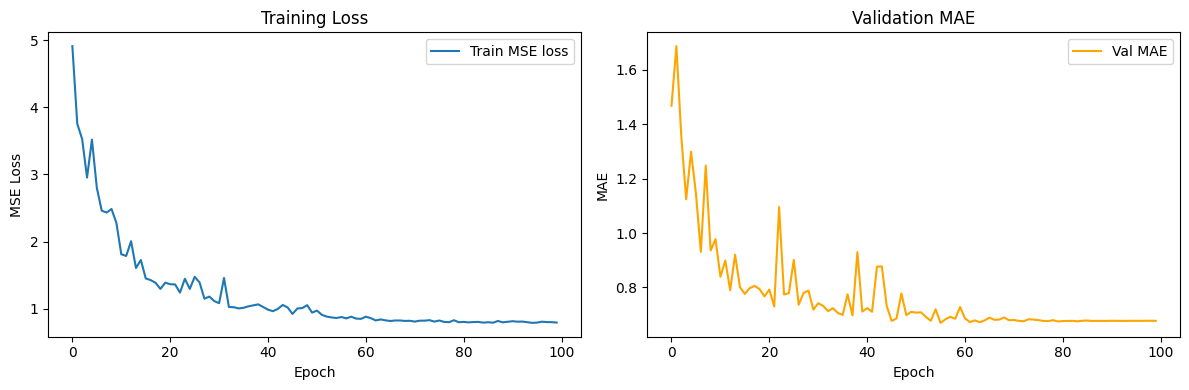

Test MAE: 0.8004


In [28]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train MSE loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(history['val_mae'], color='orange', label='Val MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].set_title('Validation MAE'); axes[1].legend()

plt.tight_layout()
plt.show()

test_mae = evaluate(model, test_loader)
print(f'Test MAE: {test_mae:.4f}')

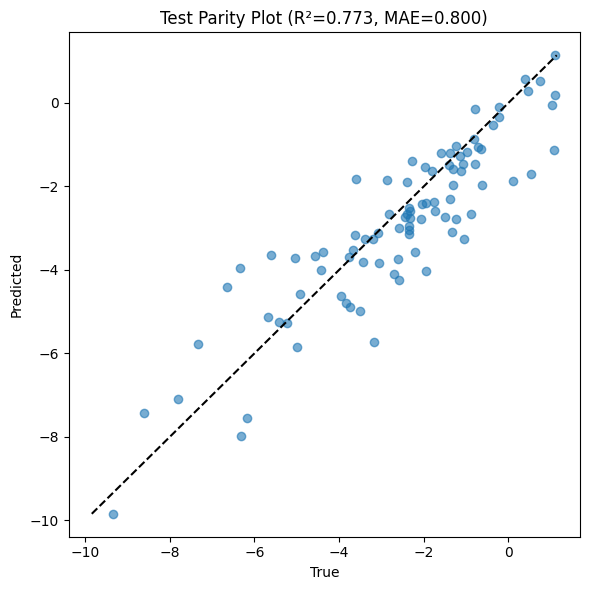

In [29]:
# Parity plot
model.eval()
preds_all, targets_all = [], []
with torch.no_grad():
    for bmg, targets in test_loader:
        preds_all.append(model(bmg).cpu())
        targets_all.append(targets)

y_pred = torch.cat(preds_all).squeeze().numpy()
y_true = torch.cat(targets_all).squeeze().numpy()

r2 = r2_score(y_true, y_pred)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], 'k--')
plt.xlabel('True'); plt.ylabel('Predicted')
plt.title(f'Test Parity Plot (R²={r2:.3f}, MAE={test_mae:.3f})')
plt.tight_layout()
plt.show()

Let's try our model for Vitamin C and A:

In [30]:
bg = BatchMolGraph([MolGraph(s) for s in ['C([C@@H]([C@@H]1C(=C(C(=O)O1)O)O)O)O']])
model(bg)

tensor([[-0.0693]], grad_fn=<AddmmBackward0>)

In [31]:
bg = BatchMolGraph([MolGraph(s) for s in ['CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C']])
model(bg)

tensor([[-3.4502]], grad_fn=<AddmmBackward0>)

Congrats, you have made your very first, very own GNN! Of course, we have made a VERY simple one here, and we could get much better results with a better architecture, e.g. a D-MPNN.

Further tutorials from me:
- [tutorial how to make a D-MPNN for molecules and reactions](https://github.com/hesther/rxn_workshop/blob/main/workshop_solution.ipynb)
- [tutorial for Chemprop and ChemTorch](https://github.com/hesther/teaching/blob/main/camlc2026/Workshop_ChemTorch_Demo.ipynb)